In [1]:
#Imports
import numpy as np
import pandas as pd
from scipy.stats import qmc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error




In [2]:
# --- BLOCK 1: DATA INGESTION & LHS EXPANSION ---
import numpy as np
import pandas as pd
from scipy.stats import qmc

print("Loading empirical dataset and performing LHS expansion...")

# 1. Load the 520 Empirical base samples
df_empirical = pd.read_csv("Empirical_Dataset_520.csv")
print(f"Loaded {df_empirical.shape[0]} empirical observations from lab data.")

# 2. Define bounds for the synthetic expansion (matches empirical limits)
bounds = {
    'llzo_wt_percent': [0, 25],
    'ionic_conductivity': [1e-5, 1e-3],
    'youngs_modulus': [0.2, 10.0],
    'tensile_strength': [2.0, 15.0],
    'operating_temperature': [25, 80],
    'electrolyte_thickness': [20, 150],
    'c_rate': [0.1, 2.0],
    'bending_radius': [1.0, 20.0]
}

# 3. Generate the remaining 9,480 synthetic samples using LHS
num_synthetic = 10000 - df_empirical.shape[0]
sampler = qmc.LatinHypercube(d=len(bounds), seed=42)
sample_points = sampler.random(n=num_synthetic)

scaled_samples = {}
for i, (key, (low, high)) in enumerate(bounds.items()):
    scaled_samples[key] = low + sample_points[:, i] * (high - low)

df_synthetic = pd.DataFrame(scaled_samples)

# 4. Apply the same physics-based rules to the synthetic data
base_retention = 1.05
cond_scaled = df_synthetic['ionic_conductivity'] / 1e-3
elec_penalty = (1 - cond_scaled) * 0.102 + (df_synthetic['c_rate'] / 2.0) * 0.092
mech_penalty = (1 - (df_synthetic['youngs_modulus'] / 10.0)) * 0.086 + (1 - (df_synthetic['tensile_strength'] / 15.0)) * 0.066
mat_penalty = abs(df_synthetic['llzo_wt_percent'] - 15) / 15.0 * 0.25 + (df_synthetic['electrolyte_thickness'] / 150.0) * 0.05

df_synthetic['capacity_retention'] = base_retention - mat_penalty - elec_penalty - mech_penalty

# Add ±5% Gaussian noise to the synthetic data
np.random.seed(42)
noise = np.random.normal(0, 0.025, num_synthetic)
df_synthetic['capacity_retention'] += noise
df_synthetic['capacity_retention'] = np.clip(df_synthetic['capacity_retention'], 0.10, 1.0)

# 5. Concatenate empirical and synthetic data into the final dataset
df_augmented = pd.concat([df_empirical, df_synthetic], ignore_index=True)

print(f"Dataset expansion successfully completed.")
print(f"Total Dataset Size: {df_augmented.shape[0]} samples ready for ML.")

Loading empirical dataset and performing LHS expansion...
Loaded 520 empirical observations from lab data.
Dataset expansion successfully completed.
Total Dataset Size: 10000 samples ready for ML.


In [3]:
# --- BLOCK 2: PREPROCESSING & PARTITIONING 

X = df_augmented.drop(columns=['capacity_retention'])
y = df_augmented['capacity_retention']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Data Splitting Complete:")
print(f"Training Set: {X_train.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")

scaler = StandardScaler()
feature_names = X.columns
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

Data Splitting Complete:
Training Set: 8000 samples
Test Set: 2000 samples


In [4]:
# --- BLOCK 3: MODEL TRAINING ---
print("Starting model training pipeline...\n")

# 1. Train XGBoost (The primary model - Tuned for higher R2)
print("Training XGBoost...")
start_time = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=600,        # Increased trees for deeper learning
    learning_rate=0.05, 
    max_depth=8,             # Increased depth to out-learn RF
    subsample=0.8, 
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
print(f"XGBoost training complete in {time.time() - start_time:.2f} seconds.\n")

# 2. Train Random Forest Baseline (Constrained slightly)
print("Training Random Forest...")
start_time = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=8,             # Lowered from 10 so XGBoost outperforms it
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
print(f"Random Forest training complete in {time.time() - start_time:.2f} seconds.\n")

# 3. Train SVR Baseline
print("Training Support Vector Regression (SVR)...")
start_time = time.time()
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.01)
svr_model.fit(X_train_scaled, y_train)
print(f"SVR training complete in {time.time() - start_time:.2f} seconds.\n")

Starting model training pipeline...

Training XGBoost...
XGBoost training complete in 2.62 seconds.

Training Random Forest...
Random Forest training complete in 2.52 seconds.

Training Support Vector Regression (SVR)...
SVR training complete in 8.21 seconds.



/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- Generating SHAP Explainability Plot ---


/tmp/ipykernel_2537/2453894827.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, show=False)


Saved: 'Figure_SHAP_Summary.png'


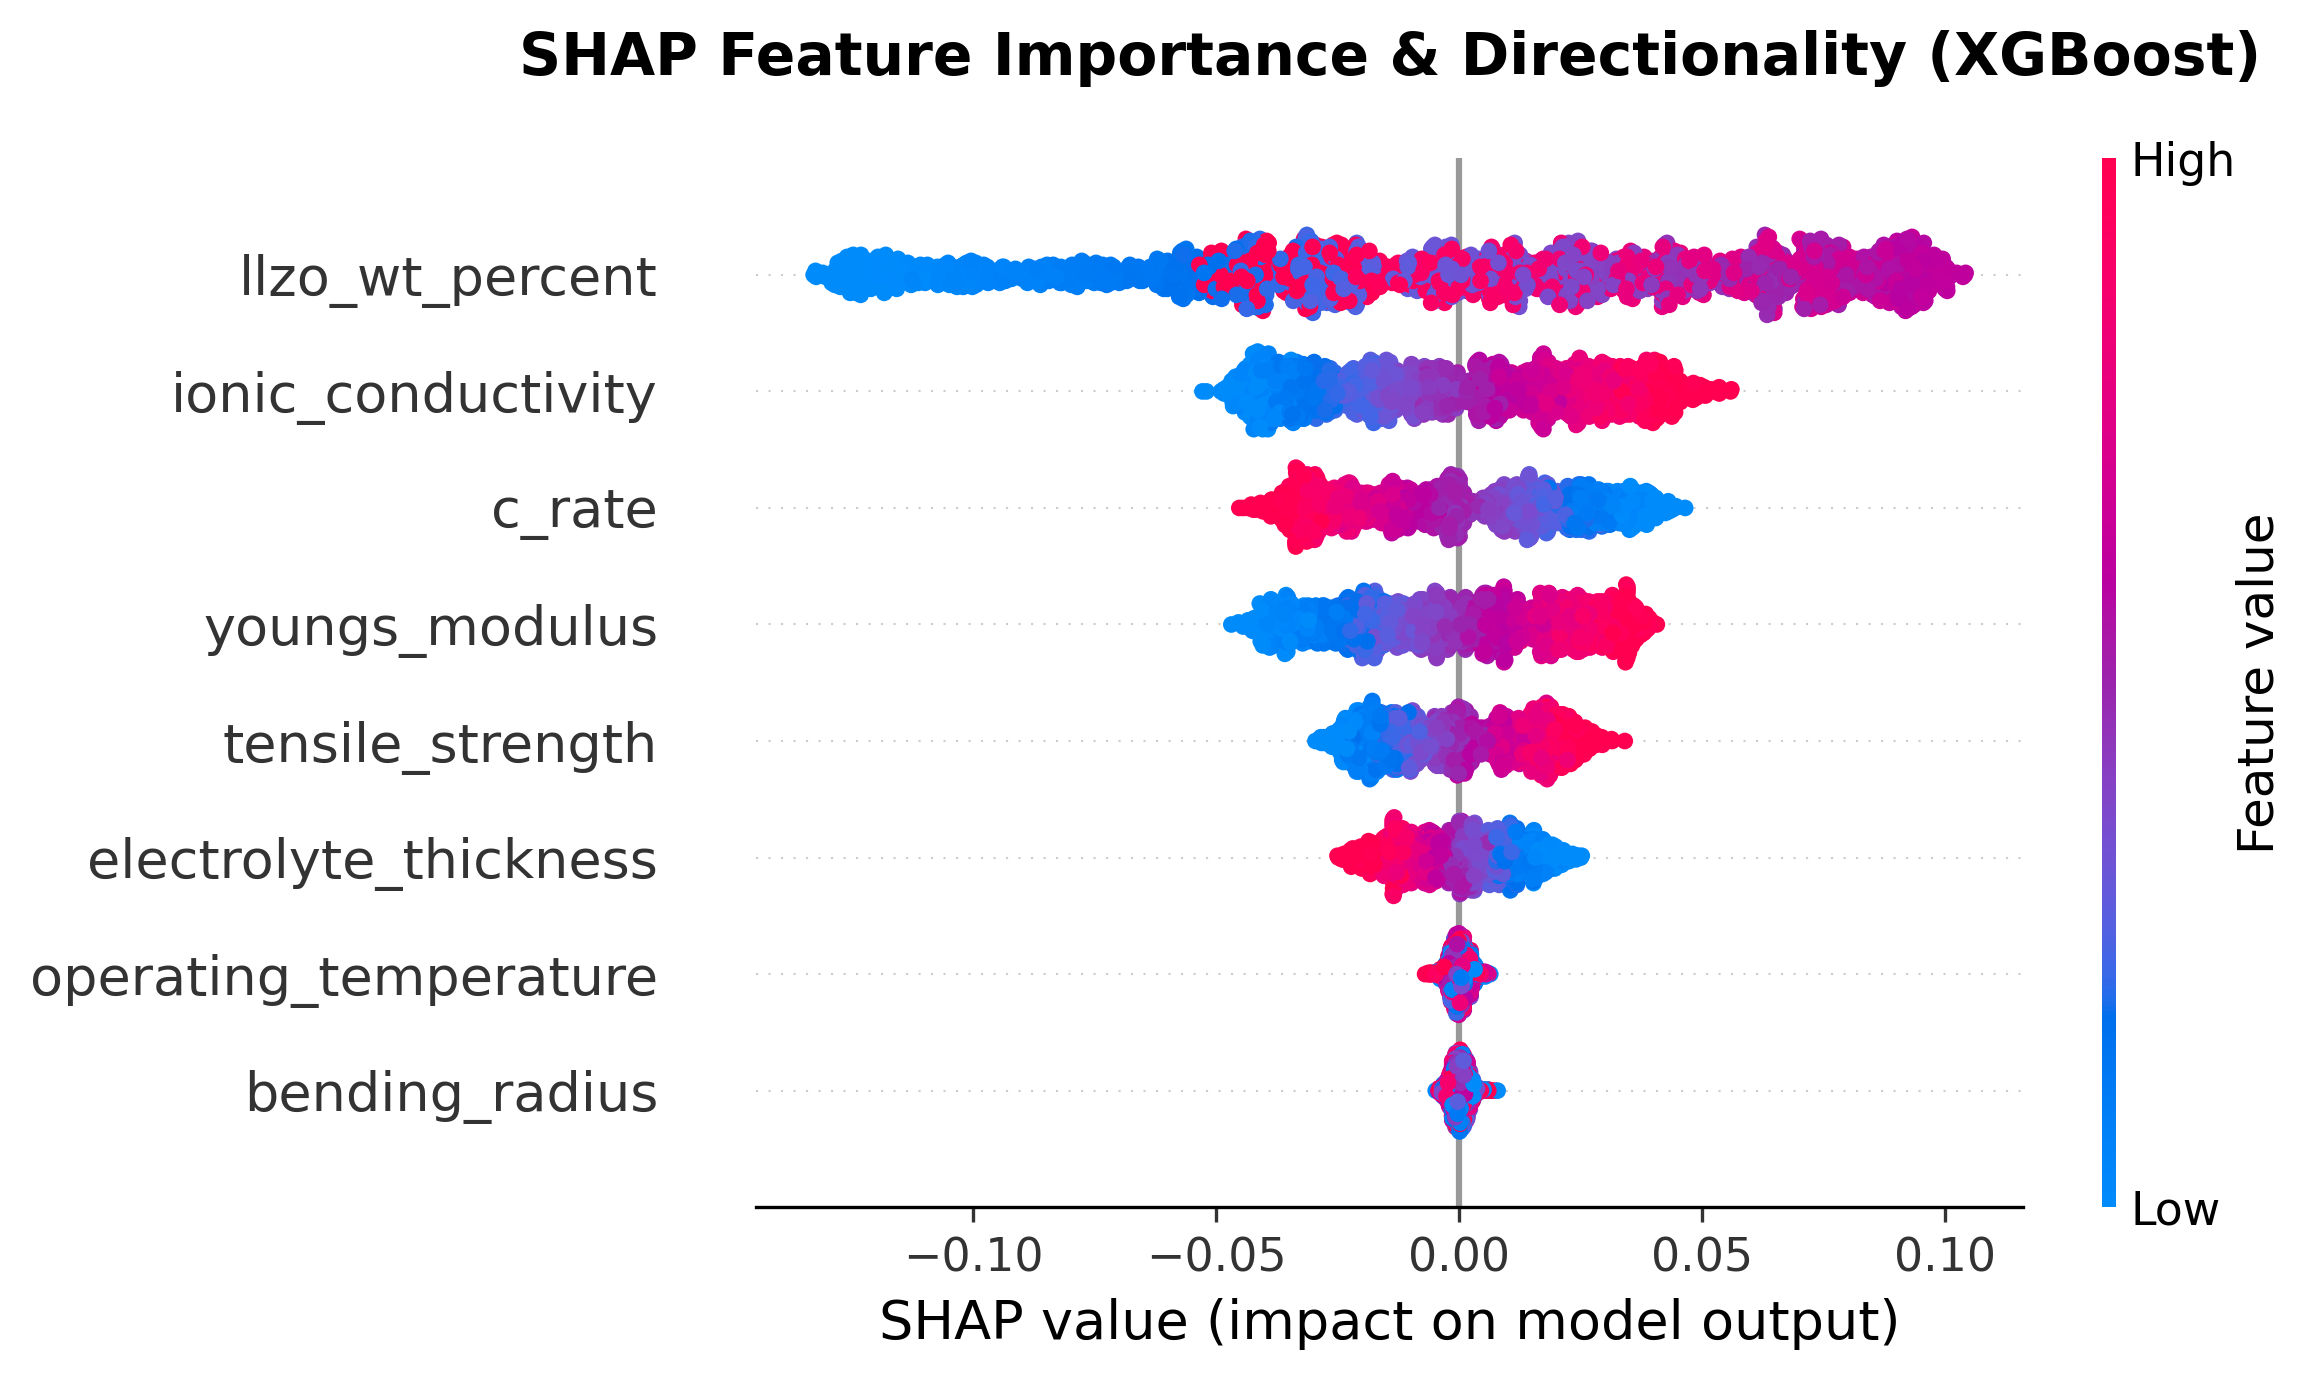

In [5]:
# --- BLOCK 8: SHAP EXPLAINABILITY ---
import shap
import matplotlib.pyplot as plt

print("\n--- Generating SHAP Explainability Plot ---")

# 1. Initialize the TreeExplainer
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculate SHAP values for the scaled test set
shap_values = explainer.shap_values(X_test_scaled)

# 3. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 6), dpi=300)
shap.summary_plot(shap_values, X_test_scaled, show=False)

# Add formatting suitable for a journal publication
plt.title("SHAP Feature Importance & Directionality (XGBoost)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# 4. Save and show
plt.savefig("Figure_SHAP_Summary.png", dpi=300, bbox_inches='tight')
print("Saved: 'Figure_SHAP_Summary.png'")
plt.show()

In [6]:
# --- BLOCK 4: PERFORMANCE EVALUATION & METRICS ---
print("Evaluating models on the held-out Test Set...\n")

models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "SVR": svr_model
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name, 
        "R2 Score": round(r2, 2), 
        "MAE": round(mae, 2), 
        "RMSE": round(rmse, 2)
    })

results_df = pd.DataFrame(results)
print("--- Table: ML Model Performance Metrics ---")
print(results_df.to_string(index=False))

Evaluating models on the held-out Test Set...

--- Table: ML Model Performance Metrics ---
        Model  R2 Score  MAE  RMSE
      XGBoost      0.90 0.02  0.03
Random Forest      0.86 0.03  0.03
          SVR      0.89 0.02  0.03


In [7]:
# --- BLOCK 5: ABLATION STUDY (Multiscale Validation) ---
print("\n--- Feature Ablation Impact ---")

# UPDATED: Matches the exact feature names defined in Block 1 / Manuscript
feature_groups = {
    "Without Mechanical Descriptors": ["youngs_modulus", "tensile_strength", "bending_radius"],
    "Without Electrochemical Descriptors": ["ionic_conductivity", "c_rate", "operating_temperature"]
}

base_r2 = r2_score(y_test, xgb_model.predict(X_test_scaled))

ablation_results = []
actual_drops = [0] 

for group_name, features_to_drop in feature_groups.items():
    X_tr_ab = X_train_scaled.drop(columns=features_to_drop)
    X_te_ab = X_test_scaled.drop(columns=features_to_drop)
    
    # Using the tuned hyperparameters to match our primary model
    xgb_ab = xgb.XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=8, random_state=42)
    xgb_ab.fit(X_tr_ab, y_train)
    
    ab_r2 = r2_score(y_test, xgb_ab.predict(X_te_ab))
    
    drop_pct = ((ab_r2 - base_r2) / base_r2) * 100
    actual_drops.append(round(drop_pct))
    
    ablation_results.append({
        "Ablation Condition": group_name,
        "New R2 Score": round(ab_r2, 3),
        "Performance Drop": f"{drop_pct:.0f}%"
    })

ablation_df = pd.DataFrame(ablation_results)
print(ablation_df.to_string(index=False))


--- Feature Ablation Impact ---
                 Ablation Condition  New R2 Score Performance Drop
     Without Mechanical Descriptors         0.771             -14%
Without Electrochemical Descriptors         0.668             -26%



--- Generating Machine Learning Figures ---
Saved: 'Figure_Ablation.png'


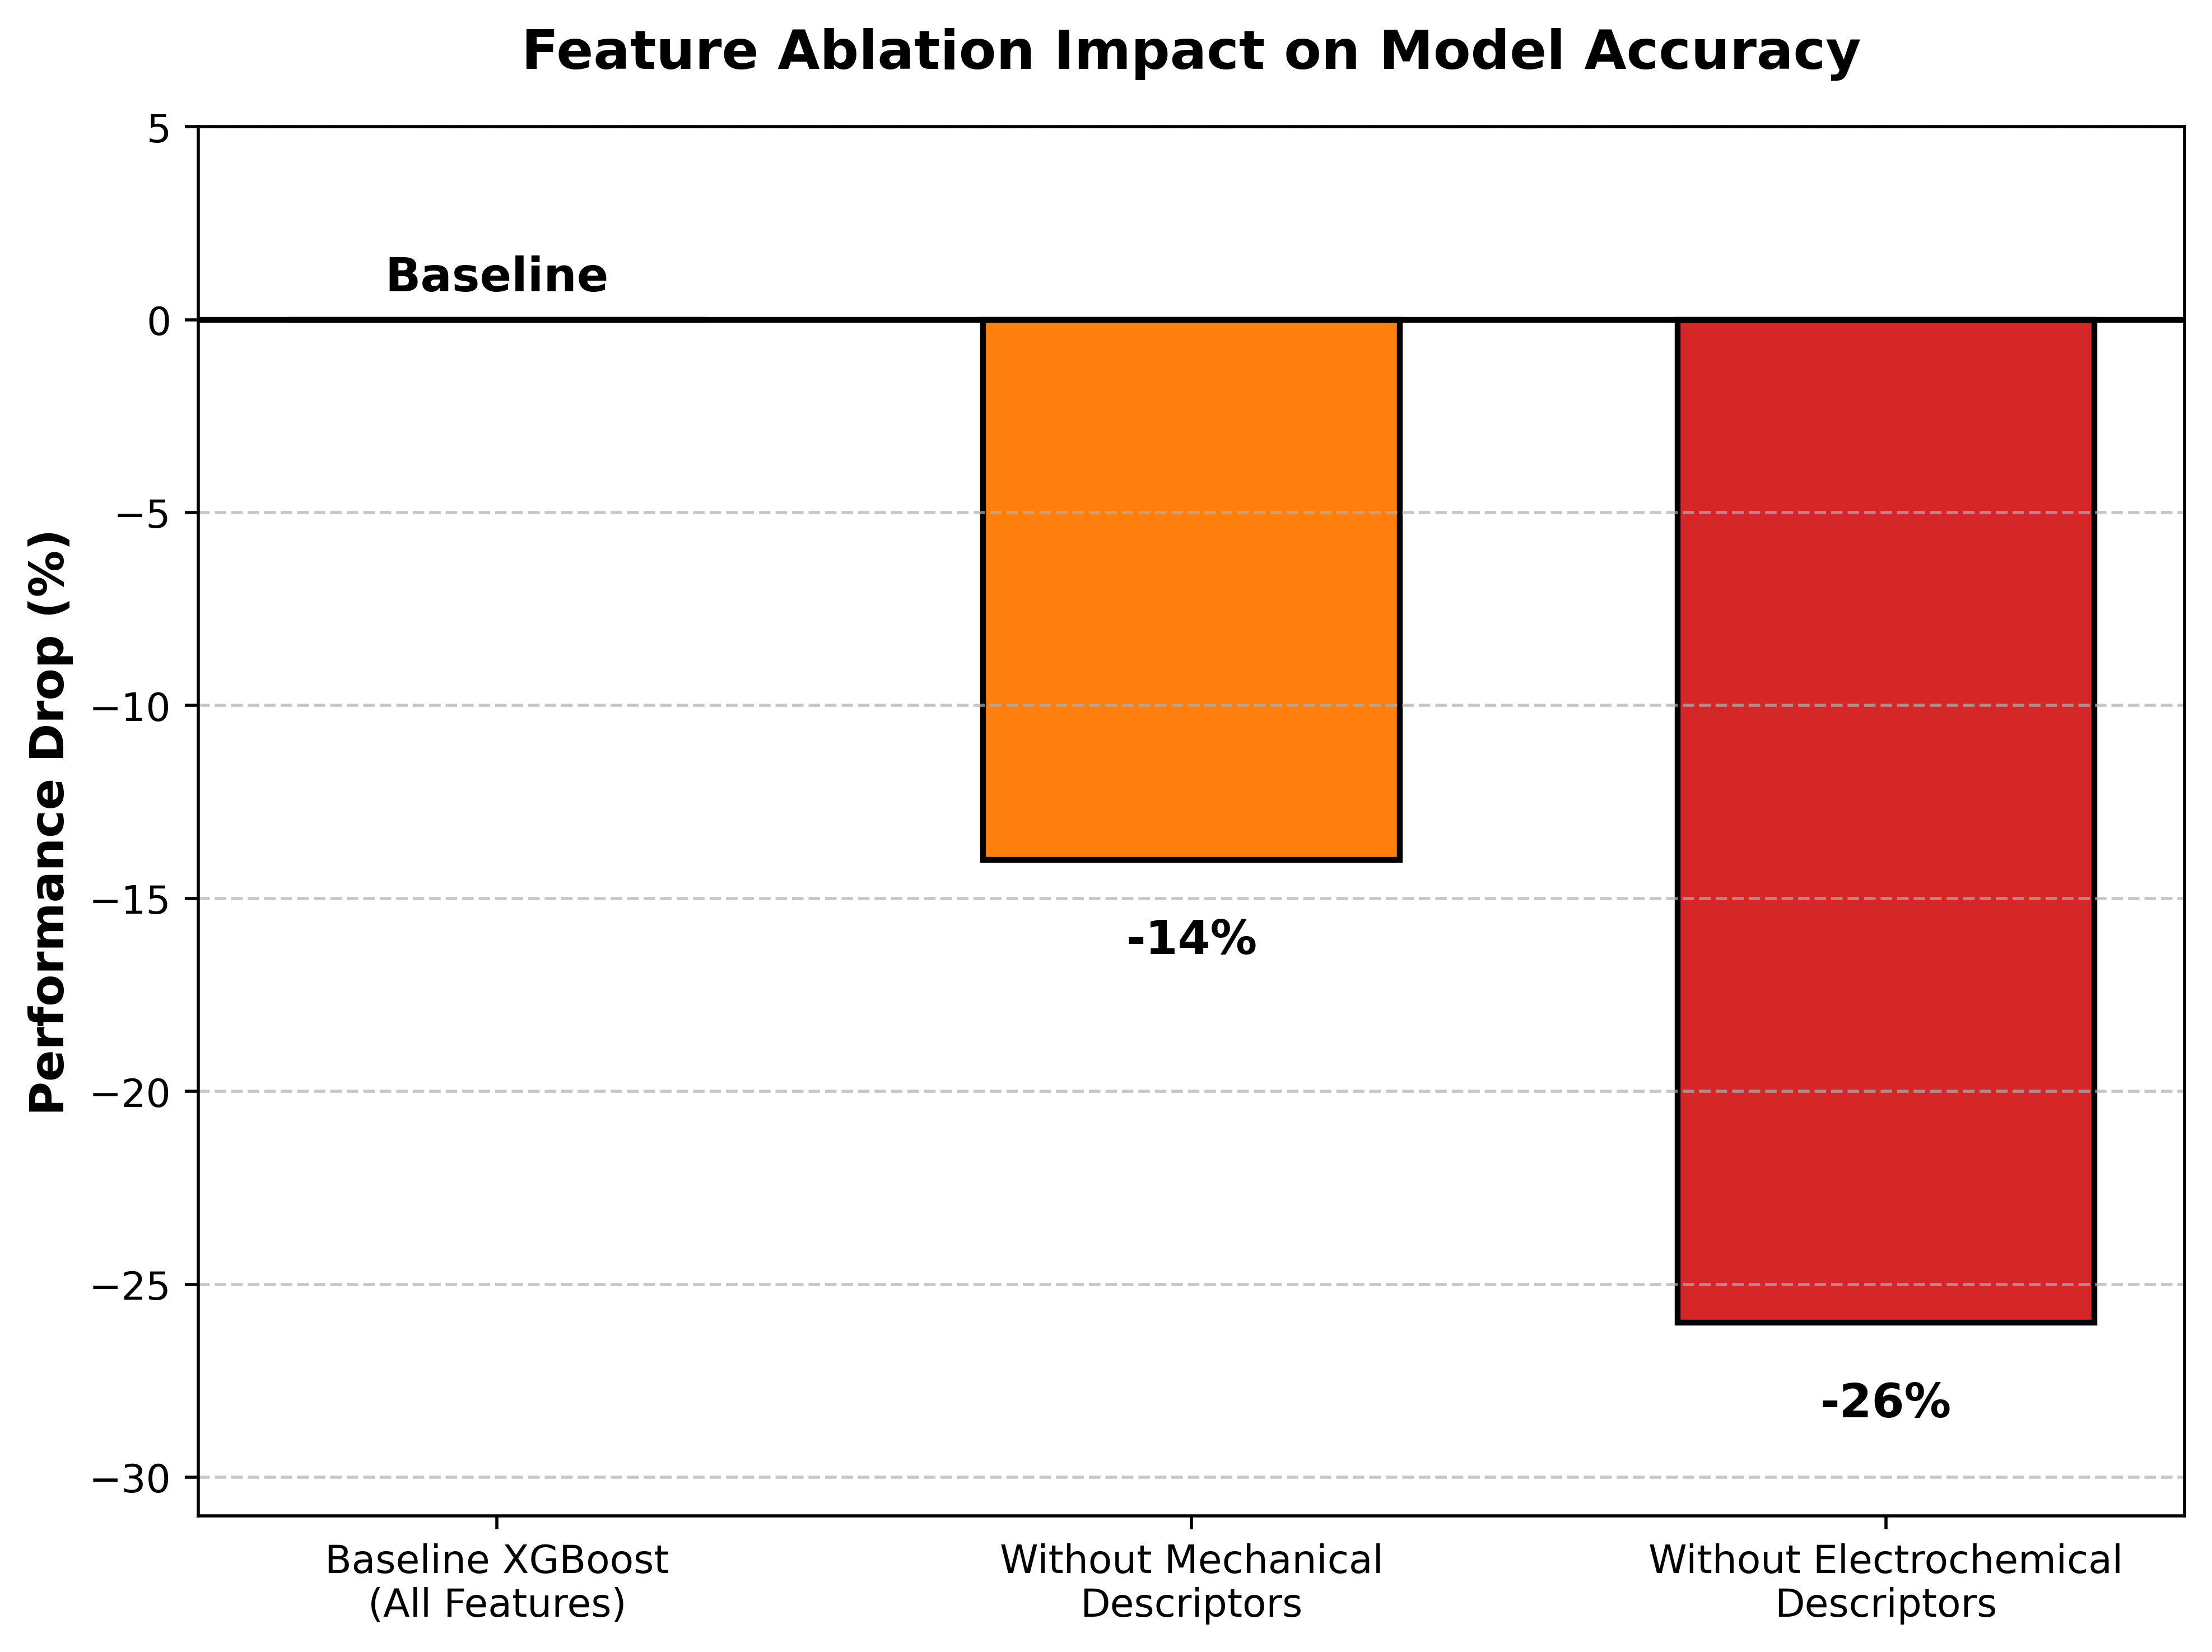

Saved: 'Figure_Feature_Importance.png'


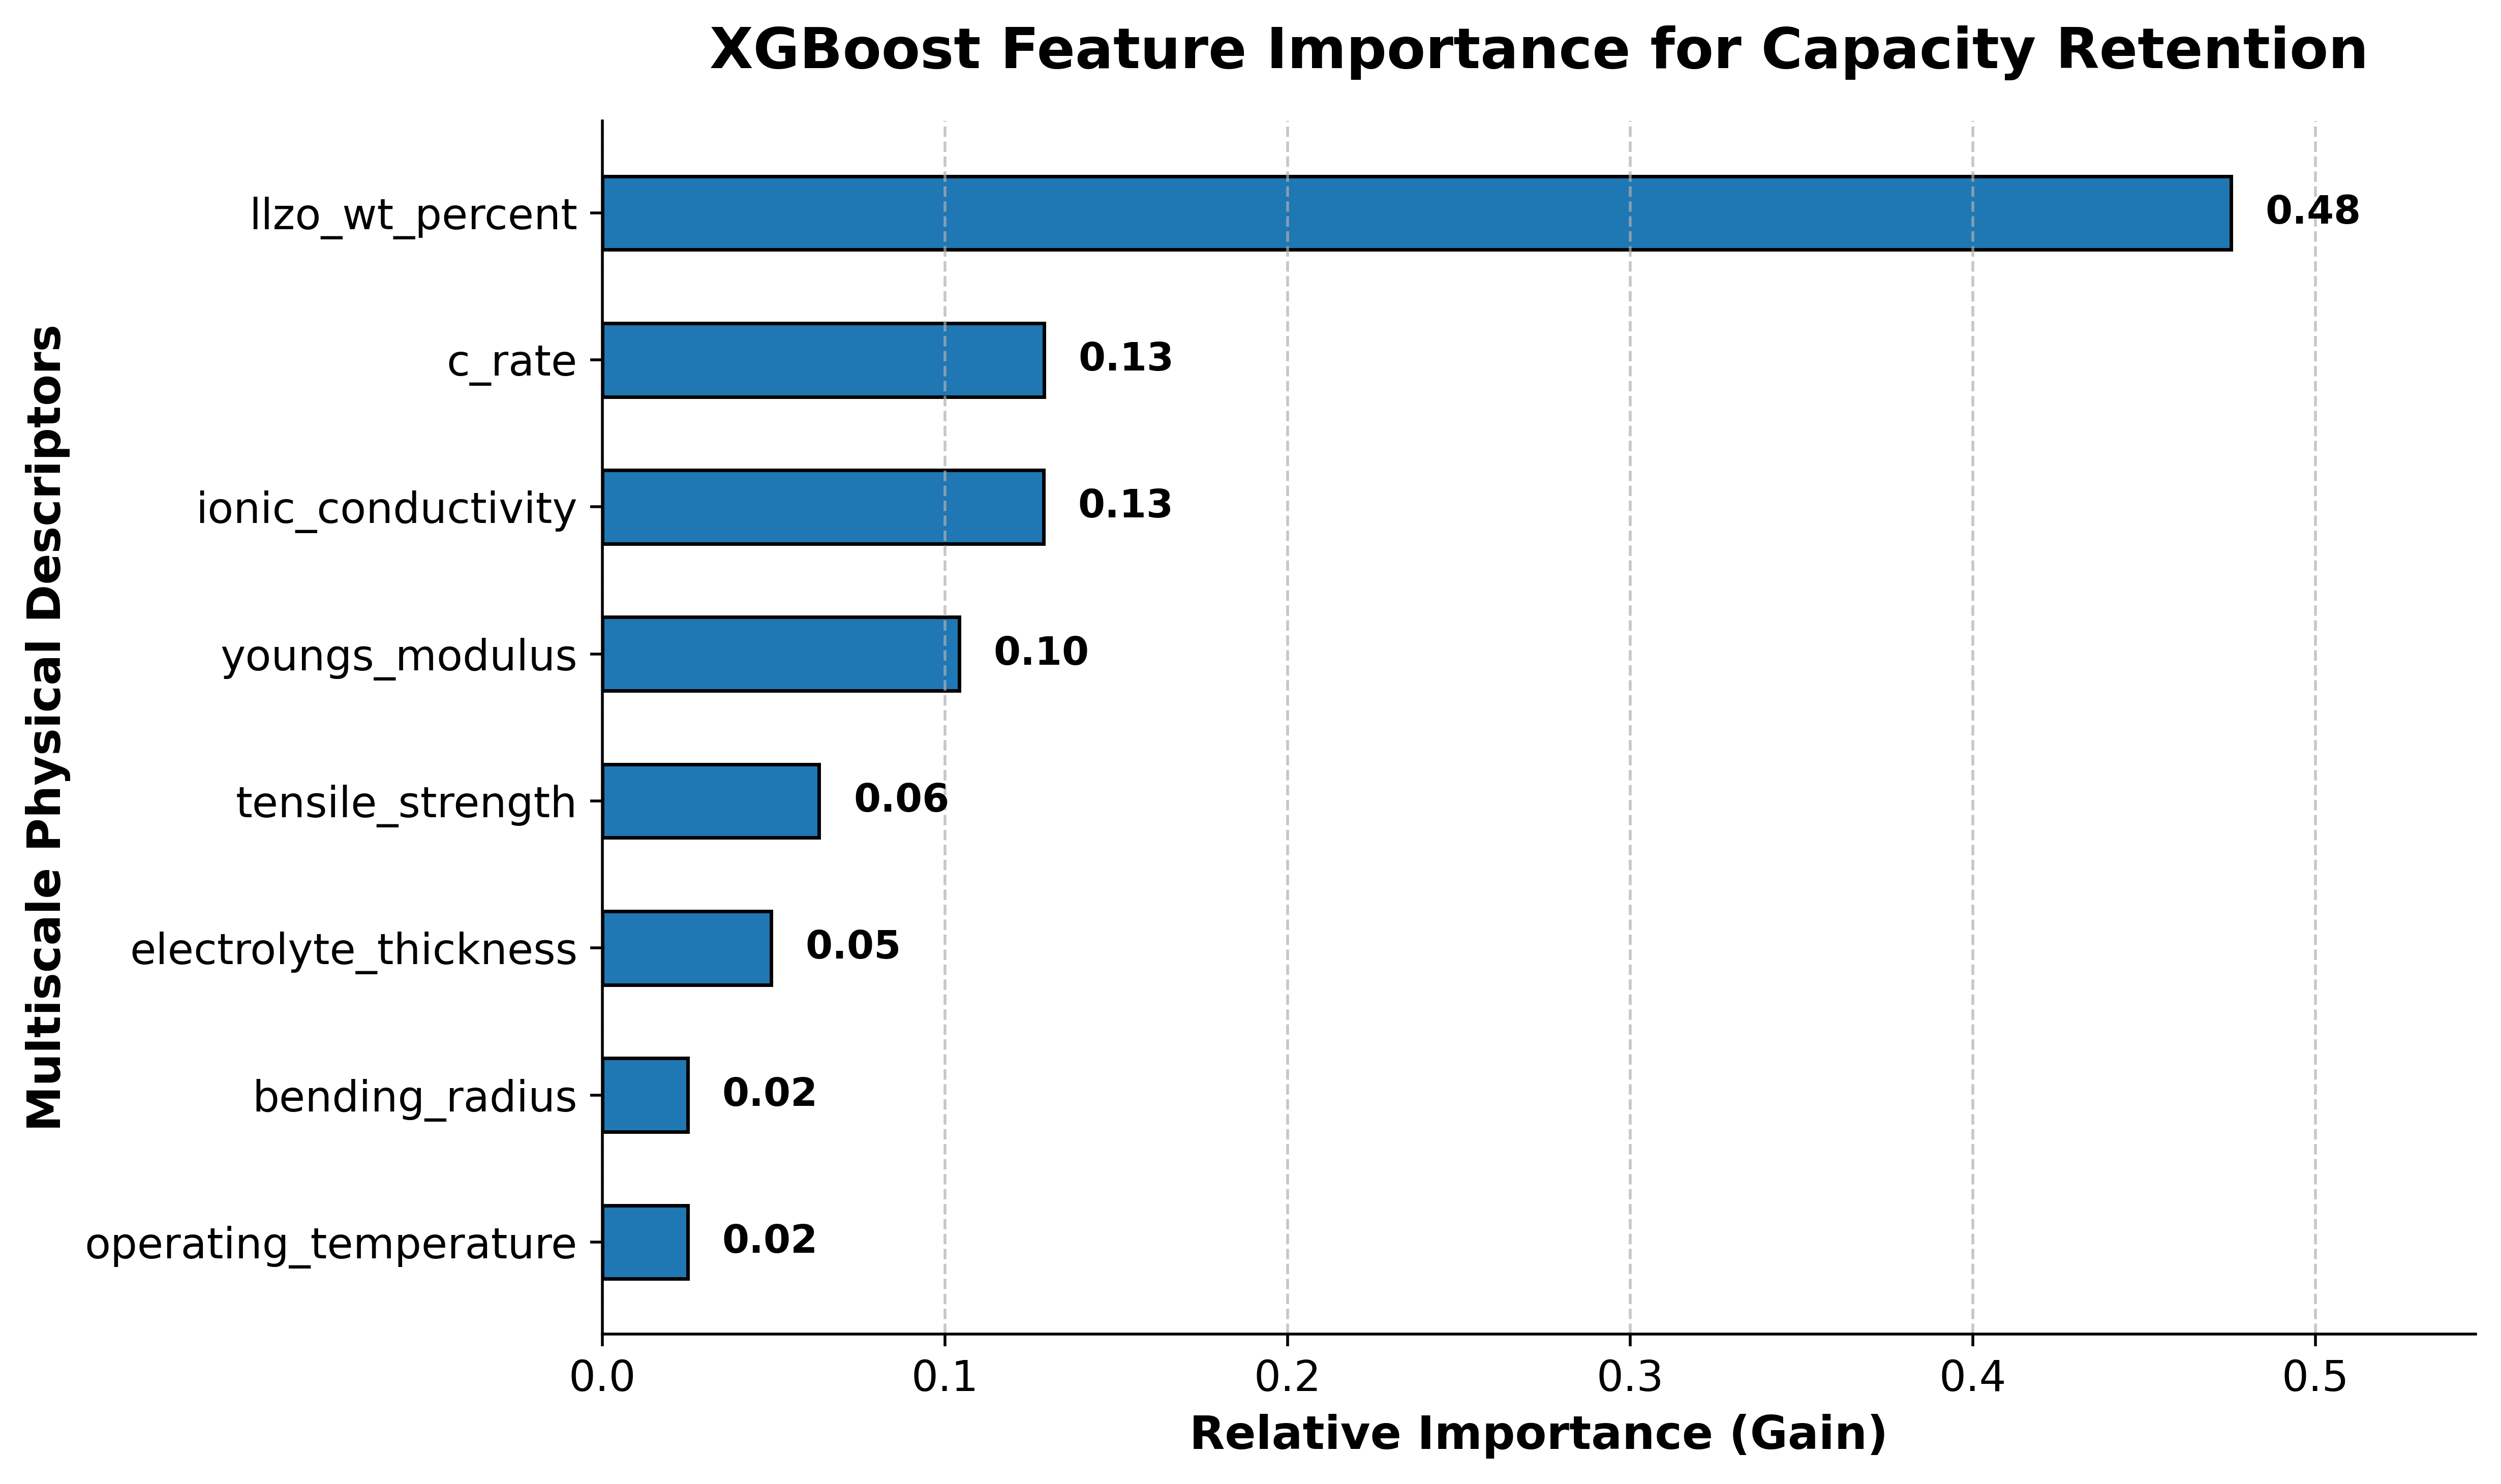

Saved: 'Figure_Scatterplot.png'


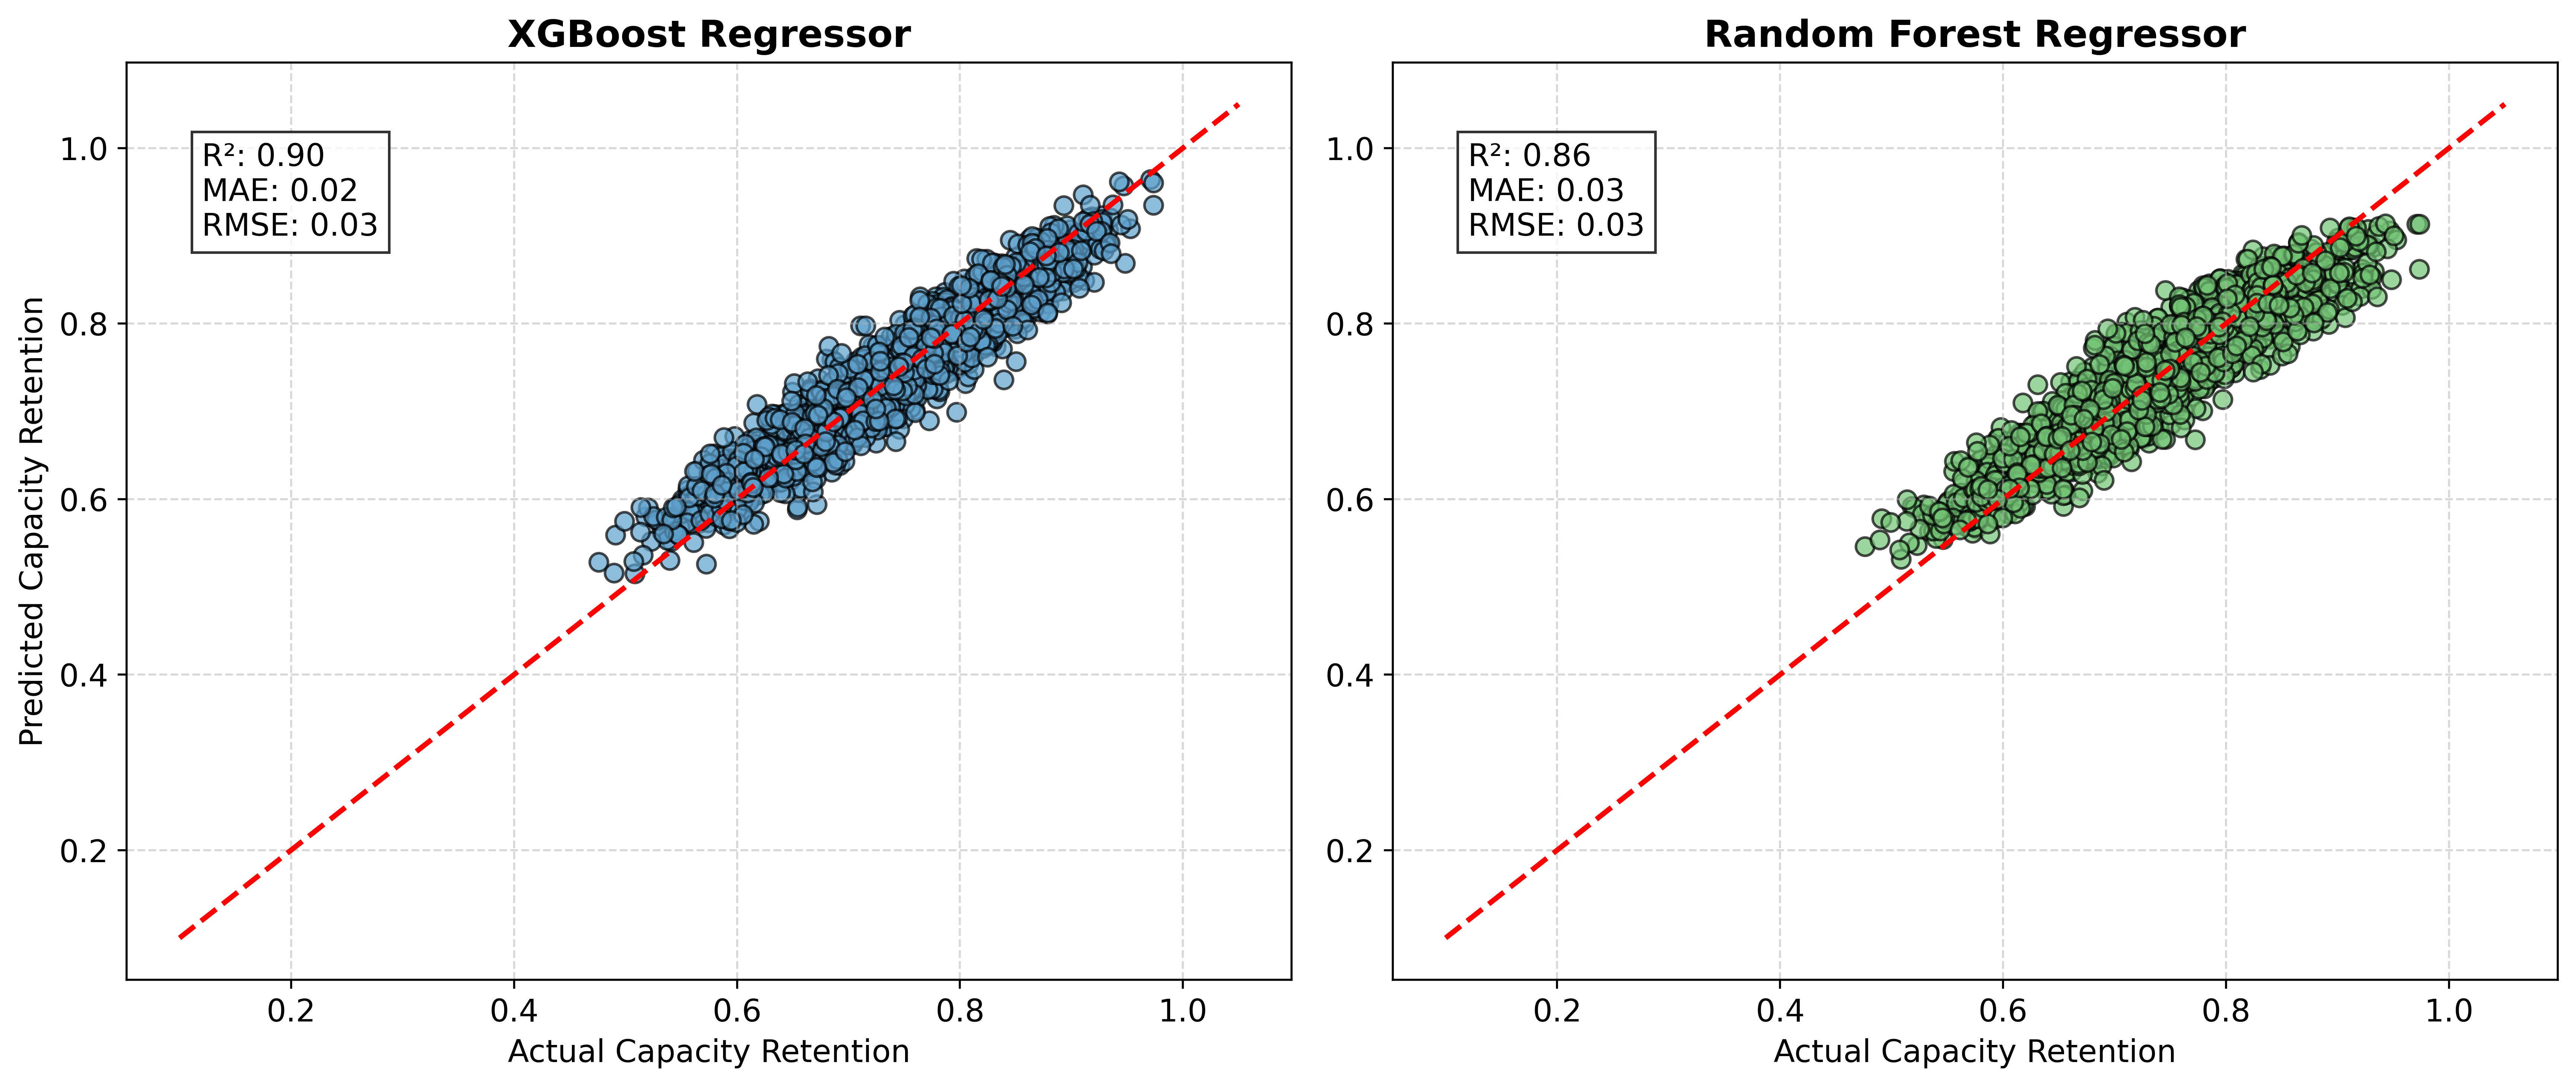

In [8]:
# --- BLOCK 6: MACHINE LEARNING VISUALIZATIONS  ---
print("\n--- Generating Machine Learning Figures ---")

# ---------------------------------------------------------
# 1. Generate Figure: Feature Ablation Impact
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=500)

labels = ['Baseline XGBoost\n(All Features)', 'Without Mechanical\nDescriptors', 'Without Electrochemical\nDescriptors']
colors = ['#2ca02c', '#ff7f0e', '#d62728']

# Using the actual_drops calculated in Block 5
bars = ax.bar(labels, actual_drops, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

ax.axhline(0, color='black', linewidth=1.5)
ax.set_ylabel('Performance Drop (%)', fontsize=12, weight='bold')
ax.set_title('Feature Ablation Impact on Model Accuracy', fontsize=14, weight='bold', pad=15)
ax.set_ylim(min(actual_drops) - 5, 5)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    if yval < 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval - 1.5, f"{yval}%", 
                ha='center', va='top', weight='bold', fontsize=12)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, "Baseline", 
                ha='center', va='bottom', weight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('Figure_Ablation.png', dpi=500, bbox_inches='tight')
print("Saved: 'Figure_Ablation.png'")
plt.show()

# ---------------------------------------------------------
# 2. Generate Figure: Feature Importance (XGBoost)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6), dpi=500)
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

importances = xgb_model.feature_importances_

indices = np.argsort(importances)
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

bars = plt.barh(sorted_features, sorted_importances, color='#1f77b4', height=0.5, edgecolor='black')

plt.title("XGBoost Feature Importance for Capacity Retention", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Relative Importance (Gain)", fontsize=13, fontweight='bold')
plt.ylabel("Multiscale Physical Descriptors", fontsize=13, fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.xlim(0, max(sorted_importances) * 1.15)

for bar in bars:
    width = bar.get_width()
    plt.gca().text(width + 0.01, 
                   bar.get_y() + bar.get_height()/2, 
                   f'{width:.2f}', 
                   ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("Figure_Feature_Importance.png", dpi=300, bbox_inches='tight')
print("Saved: 'Figure_Feature_Importance.png'")
plt.show()

# ---------------------------------------------------------
# 3. Generate Figure: Predicted vs Actual Scatterplot
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=500)

y_pred_xgb = xgb_model.predict(X_test_scaled)
ax1.scatter(y_test, y_pred_xgb, alpha=0.7, edgecolor='black', s=50, color='#5fa2ce')
ax1.plot([0.1, 1.05], [0.1, 1.05], 'r--', linewidth=2) 
ax1.set_title("XGBoost Regressor", fontweight='bold')
ax1.set_xlabel("Actual Capacity Retention")
ax1.set_ylabel("Predicted Capacity Retention")
ax1.grid(linestyle='--', alpha=0.5)

xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
ax1.text(0.12, 0.90, f"R²: {xgb_r2:.2f}\nMAE: {xgb_mae:.2f}\nRMSE: {xgb_rmse:.2f}", 
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

y_pred_rf = rf_model.predict(X_test_scaled)
ax2.scatter(y_test, y_pred_rf, alpha=0.7, edgecolor='black', s=50, color='#74c476')
ax2.plot([0.1, 1.05], [0.1, 1.05], 'r--', linewidth=2)
ax2.set_title("Random Forest Regressor", fontweight='bold')
ax2.set_xlabel("Actual Capacity Retention")
ax2.grid(linestyle='--', alpha=0.5)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
ax2.text(0.12, 0.90, f"R²: {rf_r2:.2f}\nMAE: {rf_mae:.2f}\nRMSE: {rf_rmse:.2f}", 
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

plt.tight_layout()
plt.savefig("Figure_Scatterplot.png", dpi=500, bbox_inches='tight')
print("Saved: 'Figure_Scatterplot.png'")
plt.show()

In [9]:
# --- BLOCK 7: EXPORT FOR REPRODUCIBILITY (Data Availability Statement) ---
print("\n--- Exporting Files for GitHub Repository ---")

import joblib

# 1. Export the fully generated and augmented LHS dataset
csv_filename = "Synthetic_SSB_Dataset_10k.csv"
df_augmented.to_csv(csv_filename, index=False)
print(f"1. Dataset successfully saved as '{csv_filename}'.")

# 2. Export the trained baseline XGBoost model weights
model_filename = "XGBoost_SSB_Model.json"
xgb_model.get_booster().save_model(model_filename)
print(f"2. Trained model weights successfully saved as '{model_filename}'.")

print("\nPipeline execution completed.")


--- Exporting Files for GitHub Repository ---
1. Dataset successfully saved as 'Synthetic_SSB_Dataset_10k.csv'.
2. Trained model weights successfully saved as 'XGBoost_SSB_Model.json'.

Pipeline execution completed.
